
=== Processing G2D2_detect_seed1_outfile.h5 ===
Mask keeps 177271 samples out of 100000000
Saved: /scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_detect_seed1_outfile.dLmask.png


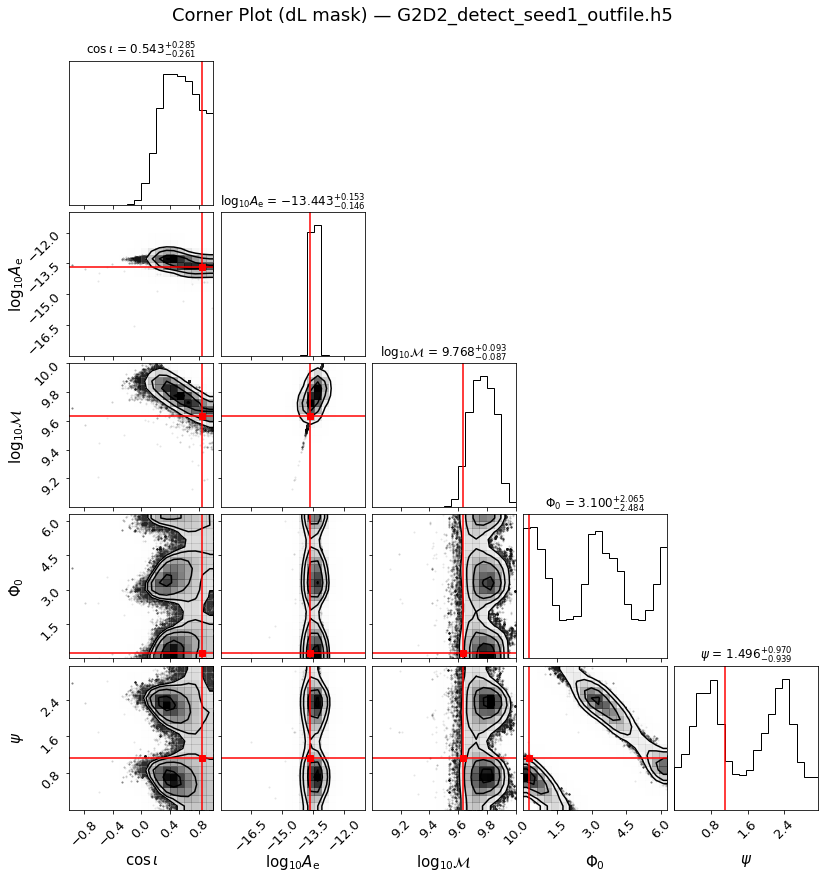


=== Processing G2D2_detect_seed2_outfile.h5 ===
Mask keeps 174963 samples out of 100000000
Saved: /scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_detect_seed2_outfile.dLmask.png


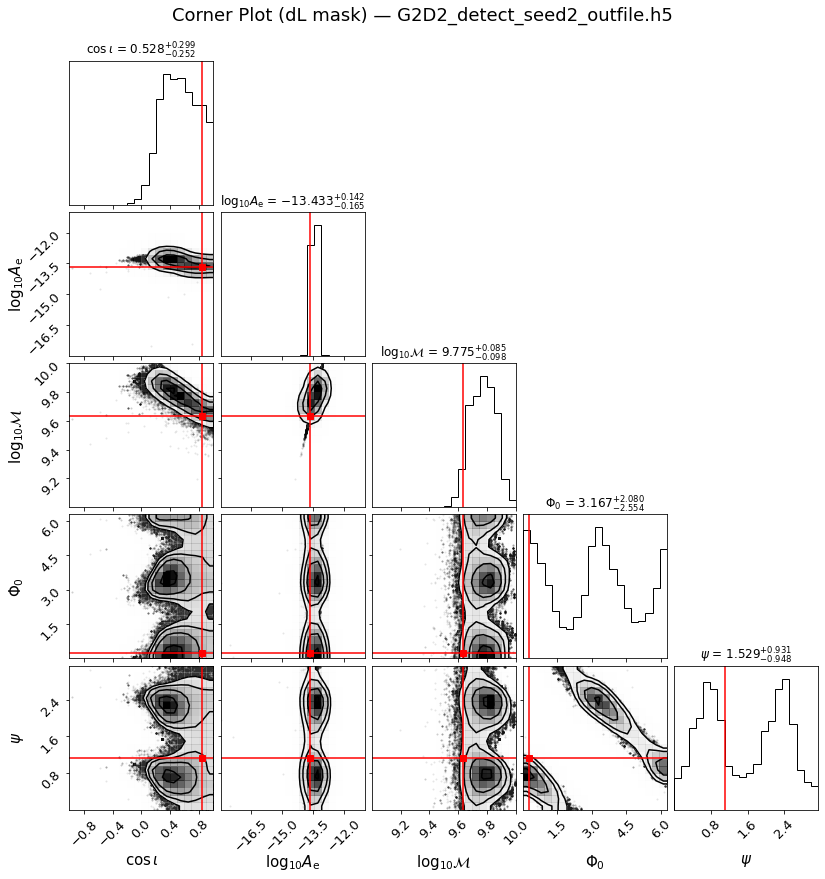


=== Processing G2D2_detect_seed3_outfile.h5 ===
Mask keeps 183235 samples out of 100000000
Saved: /scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_detect_seed3_outfile.dLmask.png


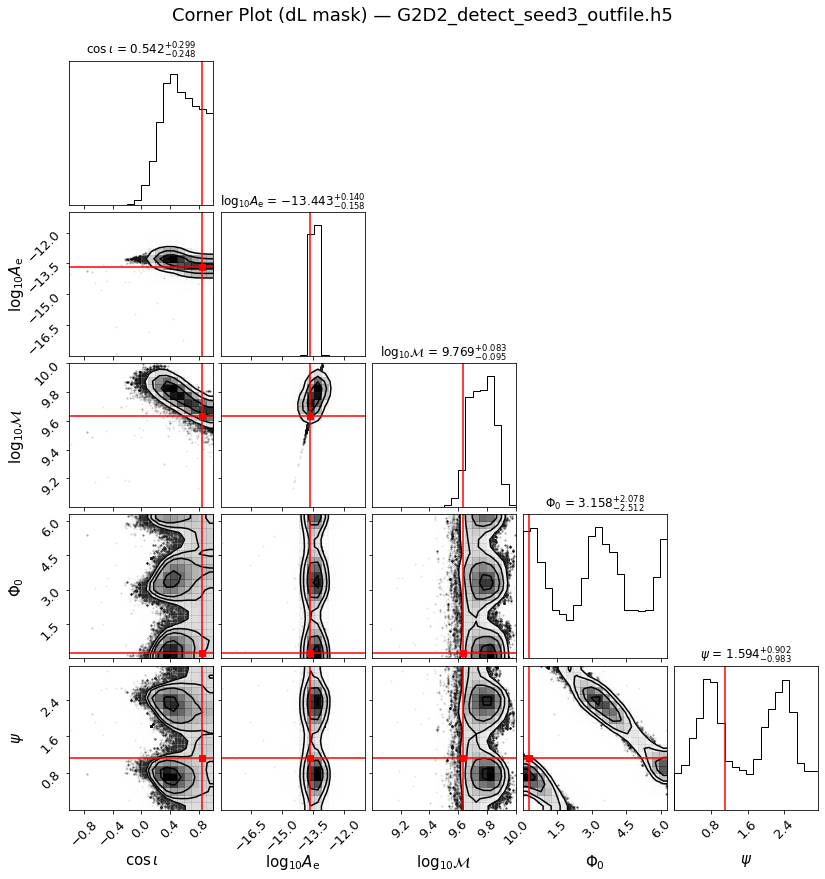


=== Processing G2D2_detect_seed4_outfile.h5 ===
Mask keeps 181261 samples out of 100000000
Saved: /scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_detect_seed4_outfile.dLmask.png


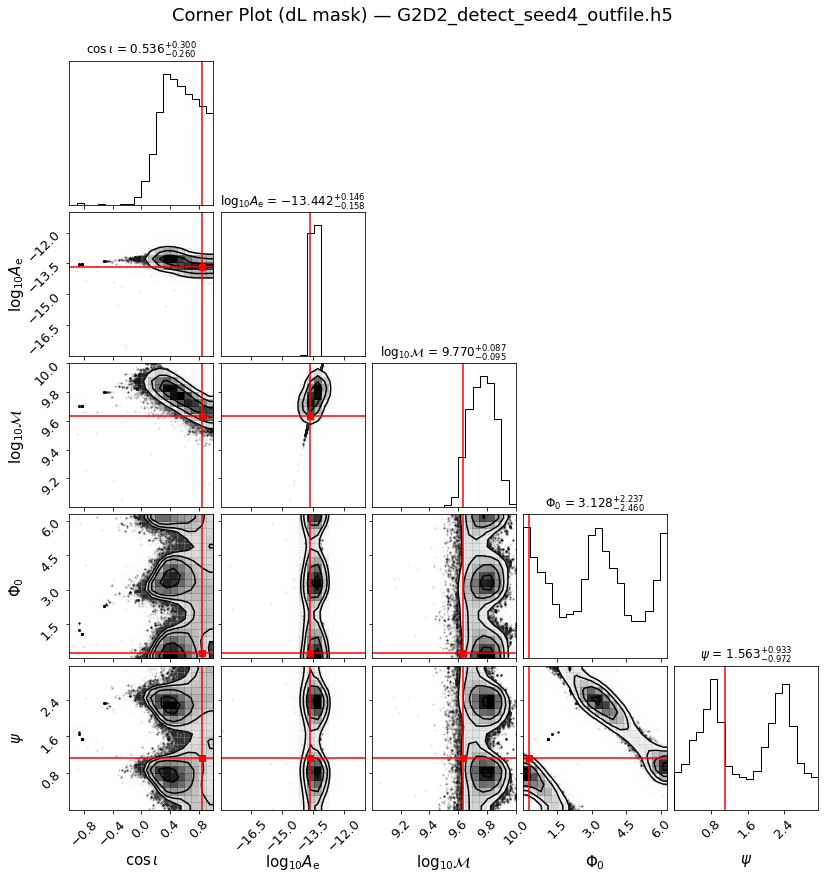


=== Processing G2D2_detect_seed5_outfile.h5 ===
Mask keeps 180991 samples out of 100000000
Saved: /scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_detect_seed5_outfile.dLmask.png


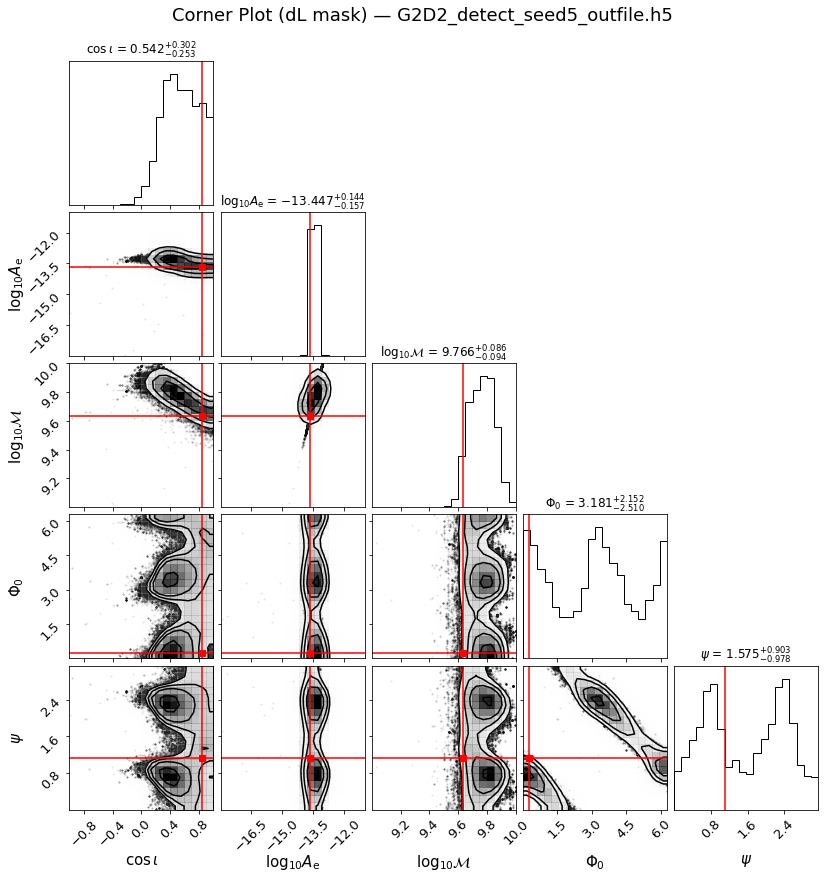

In [2]:
#!/usr/bin/env python3
import numpy as np
import h5py
import corner
import matplotlib.pyplot as plt
from pathlib import Path

# ================================================================
# USER SETTINGS
# ================================================================

base_dir = Path("/scratch/na00078/projects/IPTA_MDC2/h5_files/")
files = [
    "G2D2_detect_seed1_outfile.h5",
    "G2D2_detect_seed2_outfile.h5",
    "G2D2_detect_seed3_outfile.h5",
    "G2D2_detect_seed4_outfile.h5",
    "G2D2_detect_seed5_outfile.h5",
]

# injected luminosity distance (Mpc)
target_dL = 75.4      

# injection truths
truth = {
    "0_cos_inc": 0.8412486994612669,
    "0_log10_h": -13.668773493298787,
    "0_log10_mc": np.log10(4.3e9),
    "0_phase0": 0.24434609527920614,
    "0_psi": 1.1187560505283651,
}

labels = [
    r"$\cos \iota$",
    r"$\log_{10} A_{\rm e}$",
    r"$\log_{10} {\cal M}$",
    r"$\Phi_0$",
    r"$\psi$"
]

param_map = {
    r"$\cos \iota$": "0_cos_inc",
    r"$\log_{10} A_{\rm e}$": "0_log10_h",
    r"$\log_{10} {\cal M}$": "0_log10_mc",
    r"$\Phi_0$": "0_phase0",
    r"$\psi$": "0_psi",
}

ranges = [(-1,1), (-18,-11), (9,10), (0,2*np.pi), (0,np.pi)]

# constants for distance reconstruction
c = 299792458.0
Mpc_in_m = 3.086e22
T_sun = 4.925490947e-6   # seconds


# ================================================================
# PROCESS EACH SEED FILE
# ================================================================
for fname in files:

    infile = base_dir / fname
    print(f"\n=== Processing {infile.name} ===")

    # -------------------------------------------------------------
    # Load samples
    # -------------------------------------------------------------
    with h5py.File(infile, "r") as f:
        samples = f["samples_cold"][0]    # first chain
        par_names = [x.decode() for x in f["par_names"]]

    # indices
    idx_cos_i  = par_names.index("0_cos_inc")
    idx_logAe  = par_names.index("0_log10_h")
    idx_logfgw = par_names.index("0_log10_fgw")
    idx_logMc  = par_names.index("0_log10_mc")
    idx_phase0 = par_names.index("0_phase0")
    idx_psi    = par_names.index("0_psi")

    # -------------------------------------------------------------
    # Reconstruct luminosity distance
    # -------------------------------------------------------------
    log10_h  = samples[:, idx_logAe]
    log10_f  = samples[:, idx_logfgw]
    log10_mc = samples[:, idx_logMc]

    h_amp = 10**log10_h
    fgw   = 10**log10_f
    mc    = 10**log10_mc

    dL = (
        2 * (mc * T_sun)**(5/3) * (np.pi * fgw)**(2/3)
        / h_amp * c / Mpc_in_m
    )  # Mpc

    # -------------------------------------------------------------
    # Mask samples by distance (±1%)
    # -------------------------------------------------------------
    dL_min = target_dL * 0.99
    dL_max = target_dL * 1.01

    mask = np.where((dL >= dL_min) & (dL <= dL_max))[0]
    print(f"Mask keeps {len(mask)} samples out of {len(samples)}")

    # -------------------------------------------------------------
    # Extract masked parameter matrix for corner plot
    # -------------------------------------------------------------
    samples_plot = np.vstack([
        samples[mask, idx_cos_i],
        samples[mask, idx_logAe],
        samples[mask, idx_logMc],
        samples[mask, idx_phase0],
        samples[mask, idx_psi],
    ]).T

    # truth vector (same for all seeds)
    truths = [truth[param_map[l]] for l in labels]

    # -------------------------------------------------------------
    # Corner plot
    # -------------------------------------------------------------
    fig = corner.corner(
        samples_plot,
        labels=labels,
        truths=truths,
        truth_color="red",
        show_titles=True,
        range=ranges,
        title_fmt=".3f",
        smooth=1.0,
        hist_kwargs={"density": True},
    )

    for ax in fig.get_axes():
        ax.tick_params(axis='both', labelsize=13)
        ax.xaxis.label.set_size(15)
        ax.yaxis.label.set_size(15)

    fig.suptitle(f"Corner Plot (dL mask) — {fname}", fontsize=18, y=1.03)

    outname = infile.with_suffix(".dLmask.png")
    plt.savefig(outname, dpi=200, bbox_inches="tight")
    print(f"Saved: {outname}")

    plt.show()
